In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/complaints.csv')

df.head()

C:\Users\ruthg\AppData\Local\Temp\ipykernel_17652\4279985864.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/complaints.csv')


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [4]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [ ]:
df.isna().sum().sort_values(ascending=False).head(20)

Tags                            8981029
Consumer disputed?              8841498
Consumer complaint narrative    6629041
Company public response         4770207
Consumer consent provided?      1649561
Sub-issue                        839522
Sub-product                      235295
State                             54516
ZIP code                          30228
Company response to consumer         20
dtype: int64

In [6]:
product_counts = df['Product'].value_counts()

product_counts

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

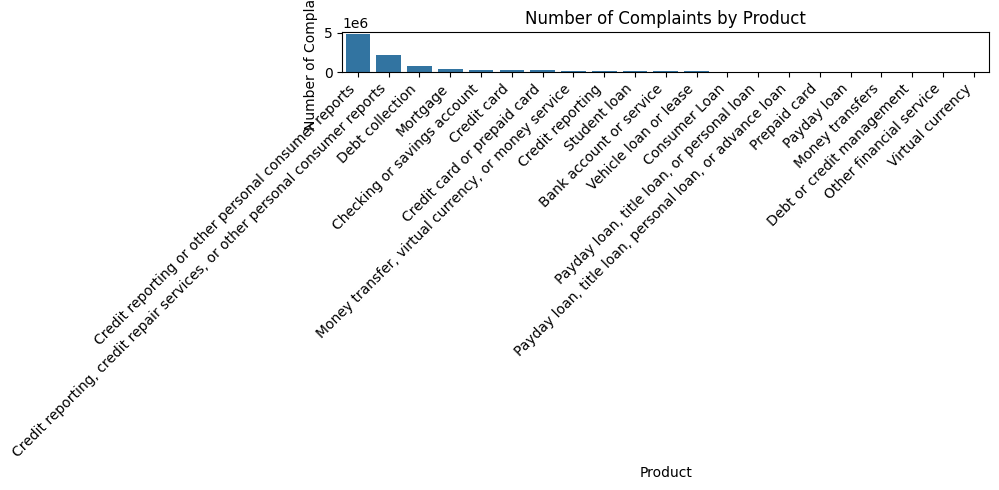

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=product_counts.index,
    y=product_counts.values
)
plt.xticks(rotation=45, ha='right')
plt.title("Number of Complaints by Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

In [8]:
df['narrative_word_count'] = (
    df['Consumer complaint narrative']
    .astype(str)
    .apply(lambda x: len(x.split()))
)
df['narrative_word_count'].describe()


count    9.609797e+06
mean     5.515649e+01
std      1.495169e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: narrative_word_count, dtype: float64

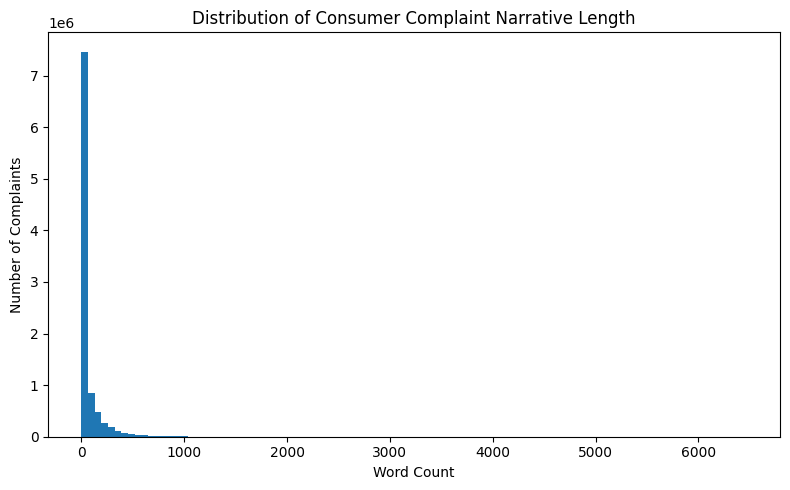

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(
    df['narrative_word_count'],
    bins=100
)
plt.title("Distribution of Consumer Complaint Narrative Length")
plt.xlabel("Word Count")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()


In [10]:
short_narratives = df[df['narrative_word_count'] <= 20]

long_narratives = df[df['narrative_word_count'] >= 1000]

len(short_narratives), len(long_narratives)


(6764612, 32489)

In [11]:
df['has_narrative'] = df['Consumer complaint narrative'].notna() & \
                      (df['Consumer complaint narrative'].str.strip() != "")


In [12]:
narrative_counts = df['has_narrative'].value_counts()

narrative_counts


has_narrative
False    6629041
True     2980756
Name: count, dtype: int64

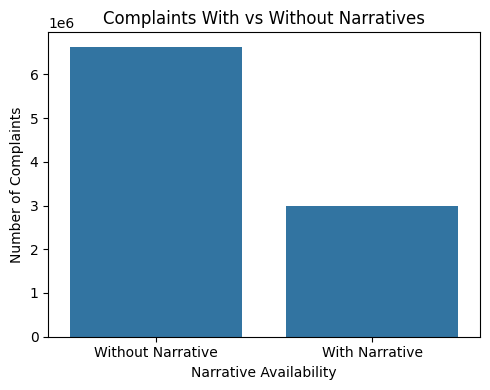

In [13]:
plt.figure(figsize=(5, 4))
sns.barplot(
    x=narrative_counts.index.map({True: "With Narrative", False: "Without Narrative"}),
    y=narrative_counts.values
)
plt.title("Complaints With vs Without Narratives")
plt.xlabel("Narrative Availability")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()


In [14]:
required_products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfers"
]

In [15]:
df_filtered = df[df['Product'].isin(required_products)]

In [16]:
df_filtered.shape

(232040, 20)

In [17]:
df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].notna() &
    (df_filtered['Consumer complaint narrative'].str.strip() != "")
]


In [18]:
df_filtered.shape

(82164, 20)

In [20]:
df_filtered.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID',
       'narrative_word_count', 'has_narrative'],
      dtype='object')

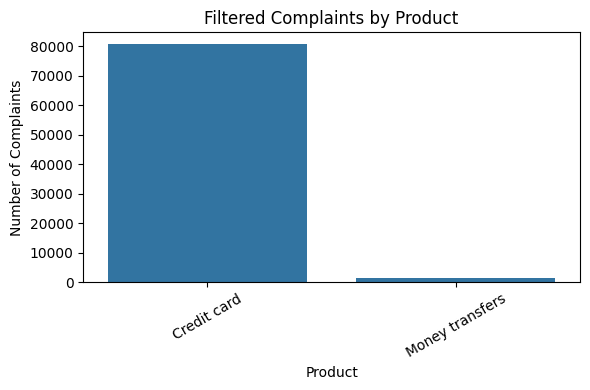

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=df_filtered['Sub-product'].value_counts().index,
    y=df_filtered['Sub-product'].value_counts().values
)
plt.xticks(rotation=30)
plt.title("Filtered Complaints by Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()
